# 📊 Day 1 — Descriptive Statistics

## Week 2 — Statistics for Machine Learning

---

### Overview

Descriptive statistics is the first step in understanding any dataset before applying machine learning algorithms.

Instead of immediately training a model, data scientists begin by exploring the data to understand its central tendency, variability, and overall distribution. These statistical summaries help identify unusual values, understand data quality, and support better preprocessing and modeling decisions.

In this notebook, we will explore the fundamental concepts of descriptive statistics and apply them to a real dataset using Python.

---

### Topics Covered

- Measures of Central Tendency
- Measures of Spread
- Percentiles and Quartiles
- Effect of Outliers
- Statistical Interpretation

## 🎯 Learning Objectives

By the end of this notebook, we will be able to:

- Calculate the mean, median, and mode of a dataset.
- Compare different measures of central tendency.
- Calculate variance, standard deviation, and the interquartile range (IQR).
- Understand how outliers influence statistical measures.
- Interpret descriptive statistics using a real-world dataset.
- Build a statistical summary before machine learning.

# Why Statistics Before Machine Learning?

Machine learning models learn patterns from data, but before building a model, we must first understand the data itself.

Descriptive statistics provides a quick summary of the dataset by answering important questions such as:

- What is the typical value?
- How much do the values vary?
- Are there any unusual observations?
- Is the data evenly distributed or skewed?

Understanding these characteristics helps us make better decisions during data preprocessing, feature engineering, and model selection.

For this reason, descriptive statistics is considered one of the most important steps in Exploratory Data Analysis (EDA).

# 📚 Libraries

We will use the following Python libraries throughout this notebook.

- **NumPy** for numerical computations.
- **Pandas** for data manipulation and analysis.
- **Matplotlib** for data visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

%matplotlib inline

In [3]:
# Load dataset
df = pd.read_csv("diabetes.csv")

## Dataset Preview

Before performing any statistical analysis, it is important to inspect the dataset and understand its structure.

This dataset contains medical information collected from female patients and is commonly used for binary classification tasks in machine learning.

Each row represents one patient, while each column represents a medical measurement or the diagnosis outcome.

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Information

Let's examine the structure of the dataset, including the number of observations, columns, and data types.

Understanding the dataset structure is an essential first step before calculating descriptive statistics.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 768
Columns: 9


## Missing Values

Missing values can affect statistical calculations and machine learning models.

First, we check whether the dataset contains any missing values.

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Observation

The dataset does not contain missing values (`NaN`). However, some medical measurements contain zero values, which may represent invalid or missing observations rather than actual measurements.

These values should be considered during the data preprocessing stage.

## Descriptive Summary

The `describe()` function provides a quick statistical summary of all numerical columns.

It includes:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

These statistics provide an initial understanding of the distribution of each feature.

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Example: The Effect of Outliers

Before analyzing a real dataset, let's explore a simple example to understand how outliers influence descriptive statistics.

The following dataset contains one extreme value (100), which allows us to compare the behavior of the mean, median, standard deviation, variance, and IQR.

In [18]:
import numpy as np

data = np.array([10, 12, 12, 13, 100])

print("Mean:", np.mean(data))
print("Median:", np.median(data))

Mean: 29.4
Median: 12.0


### Interpretation

The mean is **29.4**, which is much higher than most values because it is strongly affected by the outlier (100).

The median is **12**, which better represents the typical value since it is resistant to extreme observations.

This example demonstrates why the median is often preferred for skewed data or datasets containing outliers.

# Measures of Central Tendency

Measures of central tendency describe the center or the typical value of a dataset. They provide a quick summary of where most observations are located.

The three most common measures are:

- **Mean**: The arithmetic average of all values.
- **Median**: The middle value after sorting the data.
- **Mode**: The most frequently occurring value.

Choosing the appropriate measure depends on the characteristics of the data. For example, the median is generally preferred when the dataset contains outliers because it is less affected by extreme values.

In [10]:
glucose = df["Glucose"]

glucose.head()

0    148
1     85
2    183
3     89
4    137
Name: Glucose, dtype: int64

## Mean

The **mean** is the arithmetic average of all observations.

It is calculated by summing all values and dividing by the total number of observations.

The mean works well for symmetric distributions but is sensitive to extreme values (outliers).

In [11]:
mean_glucose = glucose.mean()

print(f"Mean Glucose Level: {mean_glucose:.2f}")

Mean Glucose Level: 120.89


### Interpretation

The mean represents the average glucose level of all patients in the dataset.

Because the mean is influenced by unusually high or low values, it should always be interpreted together with the median.

## Median

The **median** is the middle value after sorting the observations.

Unlike the mean, the median is resistant to outliers, making it a better measure for skewed distributions.

In [12]:
median_glucose = glucose.median()

print(f"Median Glucose Level: {median_glucose:.2f}")

Median Glucose Level: 117.00


### Interpretation

The median indicates the central observation in the dataset.

If the median differs noticeably from the mean, the distribution may be skewed or contain outliers.

## Mode

The **mode** is the value that appears most frequently in the dataset.

Unlike the mean and median, there may be more than one mode, or no unique mode at all.

In [13]:
mode_glucose = glucose.mode()

print(mode_glucose)

0     99
1    100
Name: Glucose, dtype: int64


In [14]:
print(f"Mode Glucose Level: {mode_glucose.iloc[0]}")

Mode Glucose Level: 99


In [15]:
central_tendency = pd.DataFrame({
    "Measure": ["Mean", "Median", "Mode"],
    "Value": [
        glucose.mean(),
        glucose.median(),
        glucose.mode().iloc[0]
    ]
})

central_tendency

,Measure,Value
0,Mean,120.894531
1,Median,117.000000
2,Mode,99.000000


## Central Tendency Analysis

The three measures provide different perspectives on the distribution of glucose levels.

- The **mean** summarizes the overall average.
- The **median** represents the middle observation.
- The **mode** identifies the most frequently occurring glucose value.

Comparing these measures helps determine whether the distribution is approximately symmetric or influenced by extreme observations.

If the mean is noticeably higher than the median, the data is likely right-skewed. If both values are close, the distribution is more balanced.

## Example: Measuring Data Spread

Describing the center of the data is not enough. We also need to understand how the values are distributed around that center.

The following example calculates three common measures of spread using the same dataset.

In [17]:
print("Standard Deviation:", np.std(data))
print("Variance:", np.var(data))

q1, q3 = np.percentile(data, [25, 75])

print("IQR:", q3 - q1)

Standard Deviation: 35.31345352694918
Variance: 1247.0399999999997
IQR: 1.0


### Interpretation

- The **standard deviation** measures the average distance of the observations from the mean.
- The **variance** measures the average squared deviation from the mean.
- The **IQR** measures the spread of the middle 50% of the data and is much less sensitive to outliers than the range.

Although the dataset contains an extreme value (100), the IQR remains relatively stable because it focuses only on the central portion of the data.

# Measures of Spread

Measures of central tendency describe the center of a dataset, while measures of spread describe how the data is distributed around that center.

Two datasets may have similar averages but very different levels of variability. Understanding the spread of the data helps identify consistency, variability, and potential outliers.

In this section, we will calculate:

- Range
- Variance
- Standard Deviation
- Interquartile Range (IQR)

## Range

The **range** is the difference between the largest and smallest values in a dataset.

\[
Range = Maximum - Minimum
\]

Although it is easy to calculate, the range is highly sensitive to outliers because it depends only on the minimum and maximum values.

In [20]:
range_glucose = glucose.max() - glucose.min()

print(f"Range: {range_glucose:.2f}")

Range: 199.00


### Interpretation

The range represents the total spread of glucose values in the dataset.

A large range indicates that the observations cover a wide interval. However, because it only considers the minimum and maximum values, it may not accurately represent the overall variability when outliers are present.

## Variance

Variance measures how far observations are spread from the mean.

It is calculated as the average squared distance from the mean.

Higher variance indicates greater variability within the dataset.

In [21]:
variance_glucose = glucose.var()

print(f"Variance: {variance_glucose:.2f}")

Variance: 1022.25


### Interpretation

The variance provides a numerical measure of dispersion.

Because the differences are squared, larger deviations contribute more heavily to the final value.

## Standard Deviation

The standard deviation is the square root of the variance.

Unlike variance, it is expressed in the same unit as the original data, making it easier to interpret.

A small standard deviation indicates that observations are clustered near the mean, while a larger value suggests greater variability.

In [22]:
std_glucose = glucose.std()

print(f"Standard Deviation: {std_glucose:.2f}")

Standard Deviation: 31.97


### Interpretation

The standard deviation indicates the average distance of glucose values from the mean.

This measure is widely used because it provides an intuitive understanding of data variability.

# Percentiles and Quartiles

Percentiles divide a dataset into one hundred equal parts.

Quartiles are special percentiles that divide the data into four equal sections.

- Q1 (25th percentile)
- Q2 (Median)
- Q3 (75th percentile)

These values are commonly used to summarize data and detect potential outliers.

In [24]:
q1 = glucose.quantile(0.25)
q2 = glucose.quantile(0.50)
q3 = glucose.quantile(0.75)

print(f"Q1: {q1}")
print(f"Median (Q2): {q2}")
print(f"Q3: {q3}")

Q1: 99.0
Median (Q2): 117.0
Q3: 140.25


## Interquartile Range (IQR)

The Interquartile Range (IQR) measures the spread of the middle 50% of the observations.

\[
IQR = Q3 - Q1
\]

Unlike the range, the IQR is resistant to extreme values and is widely used for identifying outliers.

In [25]:
iqr = q3 - q1

print(f"IQR: {iqr:.2f}")

IQR: 41.25


### Interpretation

The IQR summarizes the variability of the central portion of the dataset.

Since it ignores the lowest and highest 25% of observations, it provides a more robust measure of spread than the range.

In [26]:
summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Range",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Value": [
        glucose.mean(),
        glucose.median(),
        glucose.mode().iloc[0],
        range_glucose,
        variance_glucose,
        std_glucose,
        q1,
        q3,
        iqr
    ]
})

summary

,Statistic,Value
0,Mean,120.894531
1,Median,117.000000
2,Mode,99.000000
3,Range,199.000000
4,Variance,1022.248314
5,Standard Deviation,31.972618
6,Q1,99.000000
7,Q3,140.250000
8,IQR,41.250000


# Statistical Analysis

The descriptive statistics provide an overview of the glucose measurements in the dataset.

The mean and median describe the central location of the data, while the variance, standard deviation, and IQR describe its variability.

Comparing these statistics helps determine whether the distribution is symmetric, skewed, or influenced by extreme values.

These measures are essential during Exploratory Data Analysis (EDA) because they guide decisions related to data preprocessing, feature engineering, and model selection.

# 🧪 Hands-On Lab: Descriptive Statistics Analysis

## Objective

In this hands-on lab, we will apply descriptive statistics to the **Glucose** feature from the Diabetes dataset.

The goal is to summarize the data using measures of central tendency and spread, then interpret the results as a data analyst.

This exercise demonstrates how descriptive statistics helps us understand a dataset before building machine learning models.

### Step 1: Select a Numeric Feature

The **Glucose** column was selected because it is one of the most important medical measurements in the dataset and is directly related to diabetes prediction.

In [27]:
glucose = df["Glucose"]

glucose.head()

0    148
1     85
2    183
3     89
4    137
Name: Glucose, dtype: int64

### Step 2: Calculate Descriptive Statistics

We calculate the most common descriptive statistics that summarize the center and spread of the glucose values.

In [28]:
mean = glucose.mean()
median = glucose.median()
mode = glucose.mode().iloc[0]

minimum = glucose.min()
maximum = glucose.max()

range_value = maximum - minimum

variance = glucose.var()
std = glucose.std()

q1 = glucose.quantile(0.25)
q3 = glucose.quantile(0.75)

iqr = q3 - q1

### Statistical Summary

The following table summarizes all calculated descriptive statistics.

In [29]:
summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Minimum",
        "Maximum",
        "Range",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Value": [
        round(mean,2),
        round(median,2),
        round(mode,2),
        round(minimum,2),
        round(maximum,2),
        round(range_value,2),
        round(variance,2),
        round(std,2),
        round(q1,2),
        round(q3,2),
        round(iqr,2)
    ]
})

summary

,Statistic,Value
0,Mean,120.89
1,Median,117.00
2,Mode,99.00
3,Minimum,0.00
4,Maximum,199.00
5,Range,199.00
6,Variance,1022.25
7,Standard Deviation,31.97
8,Q1,99.00
9,Q3,140.25


### Step 3: Mean vs. Median

The mean and median are both measures of central tendency, but they do not always represent the data equally well.

Compare the two values and determine which one better represents a typical glucose measurement.

In [30]:
print(f"Mean   : {mean:.2f}")
print(f"Median : {median:.2f}")

Mean   : 120.89
Median : 117.00


### Interpretation

The average glucose level is **120.89**, while the median is **117.00**.

Because the mean is higher than the median, the glucose distribution appears to be slightly right-skewed.

Therefore, the **median** is a better measure of the typical glucose level because it is not strongly influenced by unusually high glucose values.

### Extra Step 5.1: Histogram

A histogram helps visualize how glucose values are distributed across patients.

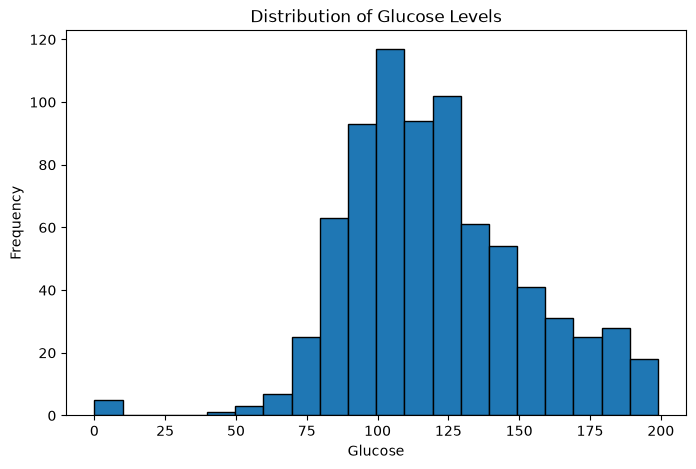

In [31]:
plt.figure(figsize=(8,5))

plt.hist(glucose, bins=20, edgecolor="black")

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

#### Interpretation

The histogram shows how glucose measurements are distributed.

Most observations are concentrated around the center, while fewer observations appear at the higher end of the distribution.

This visualization helps identify whether the data is symmetric or skewed.

### Extra Step 5.2: Box Plot

A box plot summarizes the distribution of glucose values and highlights potential outliers.

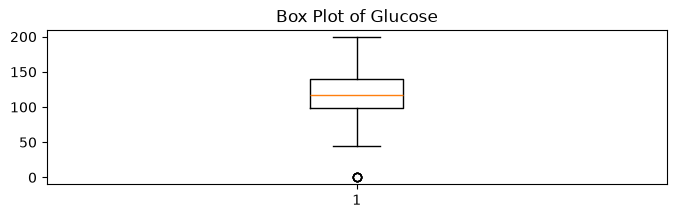

In [34]:
plt.figure(figsize=(8,2))

plt.boxplot(glucose)

plt.title("Box Plot of Glucose")

plt.show()

#### Interpretation

The box plot displays the median, quartiles, and potential outliers.

Observations outside the whiskers may indicate unusually high or low glucose values.

This plot complements the numerical statistics by providing a visual summary of the data.

# Statistical Findings

Based on the descriptive statistics:

- The mean provides the overall average glucose level.
- The median represents the central observation.
- The standard deviation indicates the variability of glucose measurements.
- The IQR summarizes the spread of the middle 50% of observations.
- The box plot suggests whether potential outliers exist.

These findings provide valuable insight into the dataset before performing feature engineering or training machine learning models.

# Reflection

This notebook demonstrated how descriptive statistics provides valuable insights before building machine learning models.

By analyzing the center and spread of the glucose measurements, we gained a better understanding of the dataset and learned how different statistical measures respond to data variability and outliers.

# Conclusion

Descriptive statistics is an essential component of Exploratory Data Analysis.

The calculated measures and visualizations provide a strong foundation for understanding the dataset before performing feature engineering or training machine learning models.

These techniques help ensure that future modeling decisions are based on a solid understanding of the underlying data.